# 유방암 데이터(Breast Cancer)를 활용한 Feature Importance 예측 머신러닝 모델 구축 및 평가

## 개요
- 목적: 유방암 진단 데이터를 정규화하고 탐색적 데이터 분석(EDA)을 수행한 뒤, 다양한 머신러닝 분류 알고리즘을 적용하여 최적의 예측 성능을 가진 모델을 도출합니다.
- 대상 데이터: Scikit-learn 제공 유방암 진단 데이터셋 (샘플 수: 569개, 특성 수: 30개)
- 핵심 기술: 탐색적 데이터 분석(EDA, 데이터 분포 확인), 로지스틱 회귀(Logistic Regression), 랜덤 포레스트(Random Forest), 하이퍼파라미터 탐색(GridSearchCV), 데이터 불균형 처리(SMOTE), 혼동 행렬(Confusion Matrix) 평가.

In [ ]:
# 0. 라이브러리 호출
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [ ]:
# 1. 데이터 불러오기
breast_cancer = load_breast_cancer()

X = pd.DataFrame(breast_cancer.data, columns=breast_cancer.feature_names)
y = pd.Series(breast_cancer.target).astype('category').cat.codes    # malignant: 0, benign: 1

print(f"데이터 크기: {X.shape}")
print(f"\n피처 목록:\n{list(X.columns)}")
print(f"\n클래스 분포:\n{y.value_counts()}")
print(f"\n클래스 분포 정규화: \n{y.value_counts(normalize=True)}")

데이터 크기: (569, 30)

피처 목록:
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']

클래스 분포:
1    357
0    212
Name: count, dtype: int64

클래스 분포 정규화: 
1    0.627417
0    0.372583
Name: proportion, dtype: float64


In [ ]:
# 2. 학습/테스트 데이터 분리하기
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"\nTrain 클래스 분포:\n{y_train.value_counts()}")
print(f"\nTest 클래스 분포:\n{y_test.value_counts()}")

Train: (455, 30), Test: (114, 30)

Train 클래스 분포:
1    285
0    170
Name: count, dtype: int64

Test 클래스 분포:
1    72
0    42
Name: count, dtype: int64


In [ ]:
# SMOTE 적용해서 분리하기
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# 결과 확인
print("\n[SMOTE 적용 전 학습 데이터 분포]")
print(y_train.value_counts())

print("\n[SMOTE 적용 후 학습 데이터 분포]")
print(y_train_resampled.value_counts())


[SMOTE 적용 전 학습 데이터 분포]
1    285
0    170
Name: count, dtype: int64

[SMOTE 적용 후 학습 데이터 분포]
1    285
0    285
Name: count, dtype: int64


In [ ]:
# 3. Random Forest 모델 생성 및 하이퍼파라미터 그리드 설정
rf_clf = RandomForestClassifier(random_state=42)

# 하이퍼파라미터 그리드
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

print("Random Forest Classifier 생성")
print(f"\n파라미터 그리드:")
for param, values in param_grid.items():
    print(f"  {param}: {values}")

total_combinations = 1
for values in param_grid.values():
    total_combinations *= len(values)
print(f"\n총 조합 수: {total_combinations}개")

Random Forest Classifier 생성

파라미터 그리드:
  n_estimators: [100, 200]
  max_depth: [None, 10, 20]
  min_samples_split: [2, 5]
  min_samples_leaf: [1, 2]

총 조합 수: 24개


In [ ]:
# 4. GridSearchCV 하이퍼파라미터 탐색
print("Tuning RandomForest Classifier...")
print("(교차검증 수행 중...)\n")

grid_clf = GridSearchCV(
    rf_clf,
    param_grid,
    cv=StratifiedKFold(5),
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid_clf.fit(X_train_resampled, y_train_resampled)
print("\nGridSearchCV 완료")

Tuning RandomForest Classifier...
(교차검증 수행 중...)

Fitting 5 folds for each of 24 candidates, totalling 120 fits

GridSearchCV 완료


In [ ]:
# 5. 최적화 모델 추출해서 결과 분석
best_clf = grid_clf.best_estimator_

print("[최적화 결과]")
print(f"Best Accuracy (Train CV): {grid_clf.best_score_:.4f}")
print(f"\nBest Parameters:")

for param, value in grid_clf.best_params_.items():
    print(f"  {param}: {value}")

[최적화 결과]
Best Accuracy (Train CV): 0.9667

Best Parameters:
  max_depth: None
  min_samples_leaf: 1
  min_samples_split: 5
  n_estimators: 100


In [ ]:
# 6. GridSearchCV 상위 5개 결과 확인
cv_results = pd.DataFrame(grid_clf.cv_results_)
top_results = cv_results.nlargest(5, 'mean_test_score')[[
    'param_n_estimators',
    'param_max_depth',
    'param_min_samples_split',
    'param_min_samples_leaf',
    'mean_test_score',
    'std_test_score'
]]

print("\n상위 5개 파라미터 조합:")
print(top_results.to_string(index=False))


상위 5개 파라미터 조합:
 param_n_estimators param_max_depth  param_min_samples_split  param_min_samples_leaf  mean_test_score  std_test_score
                100            None                        5                       1         0.966667        0.006564
                200            None                        5                       1         0.966667        0.006564
                100            None                        2                       2         0.966667        0.006564
                200            None                        2                       2         0.966667        0.006564
                100            None                        5                       2         0.966667        0.006564


In [ ]:
# 7. 예측 및 성능 평가
y_pred = best_clf.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {test_accuracy:.4f}")
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

Test Accuracy: 0.9561

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.91      0.98      0.94        42
           1       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



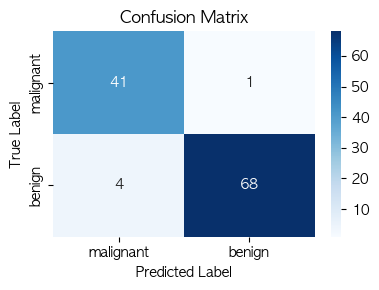

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['malignant', 'benign'],
            yticklabels=['malignant', 'benign'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

In [ ]:
# 8. feature 중요도 분석
importances = best_clf.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]

# 중요도 정렬
importance_df = pd.DataFrame({
    'Feature': feature_names[indices],
    'Importance': importances[indices]
})

print("\n피처 중요도 순위:")
print(importance_df.to_string(index=False))


피처 중요도 순위:
                Feature  Importance
             worst area    0.158571
    mean concave points    0.129508
   worst concave points    0.124273
        worst perimeter    0.088815
         mean concavity    0.064818
           worst radius    0.062339
         mean perimeter    0.061184
             area error    0.046520
        worst concavity    0.042174
            mean radius    0.039094
              mean area    0.034578
          worst texture    0.017667
      worst compactness    0.016703
       mean compactness    0.014884
           radius error    0.013434
           mean texture    0.013056
       worst smoothness    0.012133
         worst symmetry    0.008650
        perimeter error    0.007540
        mean smoothness    0.006505
        concavity error    0.005957
      compactness error    0.005380
worst fractal dimension    0.004944
   concave points error    0.003965
fractal dimension error    0.003386
         symmetry error    0.003361
          mean s

/var/folders/kf/dz21r93x3r1clgkcbjszbdjm0000gn/T/ipykernel_25859/1613946877.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=feature_names[indices], palette='viridis')


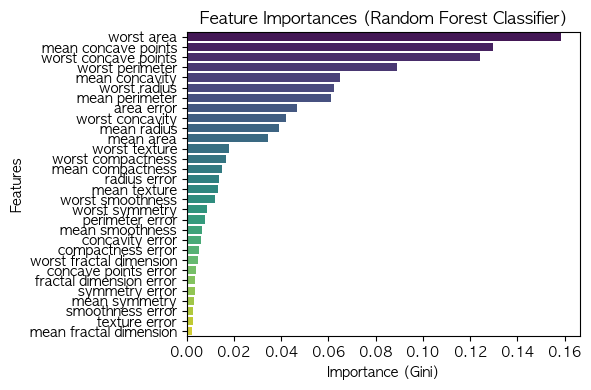

In [ ]:
# 피처 중요도 시각화
plt.figure(figsize=(6, 4))
sns.barplot(x=importances[indices], y=feature_names[indices], palette='viridis')
plt.title("Feature Importances (Random Forest Classifier)")
plt.xlabel("Importance (Gini)")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

In [ ]:
# 상위 피처들로 재학습 후 모델 비교
top_5_features = feature_names[indices[:5]]
print(f"상위 5개 피처: {list(top_5_features)}")

X_train_top5 = X_train[top_5_features]
X_test_top5 = X_test[top_5_features]

rf_top5 = RandomForestClassifier(**grid_clf.best_params_, random_state=42)
rf_top5.fit(X_train_top5, y_train)
y_pred_top5 = rf_top5.predict(X_test_top5)
accuracy_top5 = accuracy_score(y_test, y_pred_top5)

print("\n성능 비교:")
print(f"모든 피처 (8개): Accuracy = {test_accuracy:.4f}")
print(f"상위 5개 피처: Accuracy = {accuracy_top5:.4f}")
print(f"\n정확도 차이: {test_accuracy - accuracy_top5:+.4f}")

상위 5개 피처: ['worst area', 'mean concave points', 'worst concave points', 'worst perimeter', 'mean concavity']

성능 비교:
모든 피처 (8개): Accuracy = 0.9561
상위 5개 피처: Accuracy = 0.9474

정확도 차이: +0.0088
